<a href="https://colab.research.google.com/github/Amna-Sarfaraz/Python/blob/studentperformance/Loan_Default_For_Microfinance_Institution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [79]:
df=pd.read_csv('/content/Loan_Default.csv')
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [80]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [81]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [82]:
df.drop(['ID', 'year', 'approv_in_adv', 'business_or_commercial',
         'submission_of_application', 'Security_Type', 'Secured_by',
         'total_units'], axis=1, inplace=True)


In [83]:
col=['Gender','Region','loan_type','loan_purpose','co-applicant_credit_type','construction_type','occupancy_type','Neg_ammortization','interest_only','lump_sum_payment','age']
le=LabelEncoder()
for i in col:
  le.fit(df[i])
  df[i]=le.transform(df[i])

In [84]:
df.head()

,loan_limit,Gender,loan_type,loan_purpose,Credit_Worthiness,open_credit,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,...,occupancy_type,income,credit_type,Credit_Score,co-applicant_credit_type,age,LTV,Region,Status,dtir1
0,cf,3,0,0,l1,nopc,116500,NaN,NaN,NaN,...,1,1740.0,EXP,758,0,0,98.728814,3,1,45.0
1,cf,2,1,0,l1,nopc,206500,NaN,NaN,NaN,...,1,4980.0,EQUI,552,1,3,NaN,0,1,NaN
2,cf,2,0,0,l1,nopc,406500,4.56,0.2000,595.0,...,1,9480.0,EXP,834,0,1,80.019685,3,0,46.0
3,cf,2,0,3,l1,nopc,456500,4.25,0.6810,NaN,...,1,11880.0,EXP,587,0,2,69.376900,0,0,42.0
4,cf,1,0,0,l1,nopc,696500,4.00,0.3042,0.0,...,1,10440.0,CRIF,602,1,0,91.886544,0,0,39.0


In [85]:
df.isnull().sum()

,0
loan_limit,3344
Gender,0
loan_type,0
loan_purpose,0
Credit_Worthiness,0
open_credit,0
loan_amount,0
rate_of_interest,36439
Interest_rate_spread,36639
Upfront_charges,39642


In [86]:
# Categorical fill (mode)
df['loan_limit'].fillna(df['loan_limit'].mode()[0], inplace=True)
df['term'].fillna(df['term'].mode()[0], inplace=True)

# Numerical fill (median)
num_cols_median = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges',
                   'property_value', 'income', 'age', 'LTV', 'dtir1']

for col in num_cols_median:
    df[col].fillna(df[col].median(), inplace=True)


In [87]:
print(df.isnull().sum())

loan_limit                  0
Gender                      0
loan_type                   0
loan_purpose                0
Credit_Worthiness           0
open_credit                 0
loan_amount                 0
rate_of_interest            0
Interest_rate_spread        0
Upfront_charges             0
term                        0
Neg_ammortization           0
interest_only               0
lump_sum_payment            0
property_value              0
construction_type           0
occupancy_type              0
income                      0
credit_type                 0
Credit_Score                0
co-applicant_credit_type    0
age                         0
LTV                         0
Region                      0
Status                      0
dtir1                       0
dtype: int64


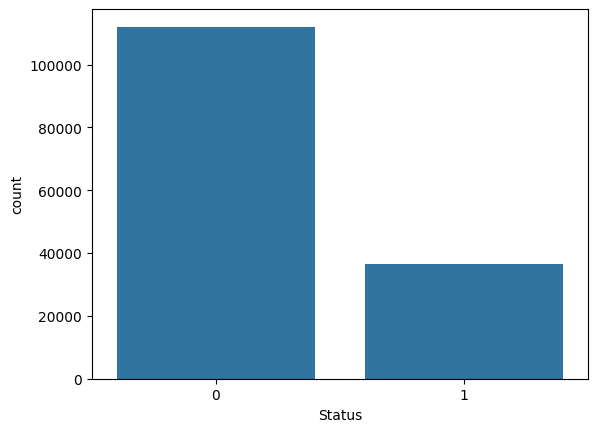

In [88]:
sns.countplot(x='Status',data=df)
plt.show()

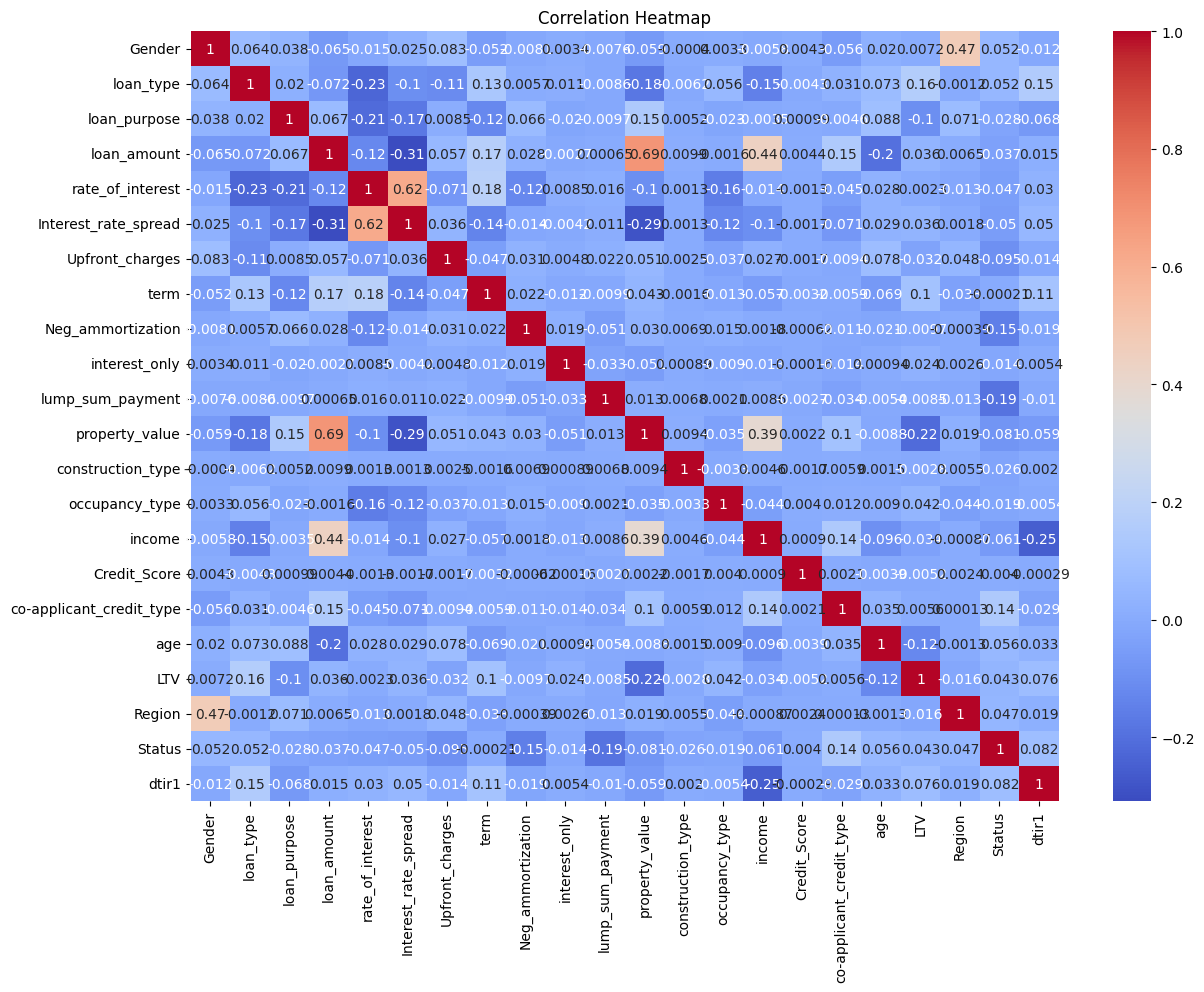

In [89]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [90]:
X = df.drop('Status', axis=1)
y = df['Status']
X=pd.get_dummies(X)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
stratify=y, random_state=42)

In [91]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [92]:
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy:  1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

Confusion Matrix:
 [[22406     0]
 [    0  7328]]


In [104]:
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})

# Display first 20 comparisons
print(comparison.head(50))

    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          0
18       0          0
19       0          0
20       1          1
21       0          0
22       0          0
23       0          0
24       0          0
25       0          0
26       0          0
27       1          1
28       0          0
29       0          0
30       0          0
31       0          0
32       0          0
33       1          1
34       0          0
35       1          1
36       0          0
37       0          0
38       0          0
39       0          0
40       0          0
41       0          0
42       0          0
43       1          1
44       1